## Import Libraries

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment

## Load Data

In [132]:
train_df = pd.read_excel("Modtrain.xlsx")
train_df.head()

,gr,x1,x2,obs id
0,1,90.535,102.132,1
1,1,96.539,101.255,2
2,1,102.514,93.208,3
3,1,104.786,105.752,4
4,1,95.393,100.954,5


In [133]:
test_df = pd.read_excel("Modtest.xlsx")
test_df.head()

,gr,x1,x2,Obs id
0,1,89.670,90.763,6
1,1,105.569,104.501,7
2,1,97.543,99.018,8
3,1,100.446,98.710,9
4,1,100.735,94.586,14


In [134]:
# Split train data into X and y
X_train = train_df[['x1', 'x2']]
y_train = train_df[['gr']]

X_test = test_df[['x1', 'x2']]
y_test = test_df[['gr']]

## LDA

In [135]:
# LDA as a supervised classifier
lda_clf = LinearDiscriminantAnalysis(store_covariance=True)
lda_clf.fit(X_train, y_train)

/Users/vishalbhaga/Documents/University/Year 1/MIT801/Exam/SL/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",True
,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide <array_api>` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None
Name,Type,Value
"classes_ classes_: array-like of shape (n_classes,)Unique class labels.","ndarray[int64](3,)","[1,2,3]"
"coef_ coef_: ndarray of shape (n_features,) or (n_classes, n_features)Weight vector(s).","ndarray[float64](3, 2)","[[-0.05,-0.33], [ 0.31,-0.32], [-0.24, 0.48]]"
"covariance_ covariance_: array-like of shape (n_features, n_features)Weighted within-class covariance matrix. It corresponds to`sum_k prior_k * C_k` where `C_k` is the covariance matrix of thesamples in class `k`. The `C_k` are estimated using the (potentiallyshrunk) biased estimator of covariance. If solver is 'svd', onlyexists when `store_covariance` is True.","ndarray[float64](2, 2)","[[26.09,11.76], [11.76,26.57]]"


In [136]:
# Get estimates of the parameters

# Classes
classes = lda_clf.classes_

# Prior probabilities
priors = lda_clf.priors_

# Class means / centroids
means = lda_clf.means_

# Shared covariance matrix
covariance = lda_clf.covariance_

# Inverse covariance matrix
covariance_inv = np.linalg.inv(covariance)

print("Classes:")
print(classes)

print("\nPrior probabilities:")
for cls, prior in zip(classes, priors):
    print(f"Class {cls}: {prior:.4f}")

print("\nClass mean vectors:")
for cls, mean in zip(classes, means):
    print(f"Class {cls}: X1 = {mean[0]:.4f}, X2 = {mean[1]:.4f}")

print("\nShared covariance matrix:")
print(covariance)

print("\nInverse covariance matrix:")
print(covariance_inv)


Classes:
[1 2 3]

Prior probabilities:
Class 1: 0.2466
Class 2: 0.3474
Class 3: 0.4060

Class mean vectors:
Class 1: X1 = 99.8582, X2 = 100.0497
Class 2: X1 = 109.5319, X2 = 104.6407
Class 3: X1 = 104.5715, X2 = 119.3876

Shared covariance matrix:
[[26.0897324  11.76180644]
 [11.76180644 26.56801875]]

Inverse covariance matrix:
[[ 0.04788649 -0.02119961]
 [-0.02119961  0.04702442]]


In [137]:
# Classify test set
y_pred = lda_clf.predict(X_test)

# Duplicate test df and add predictions
test_results_df = test_df.copy()
test_results_df["gr_pred"] = y_pred

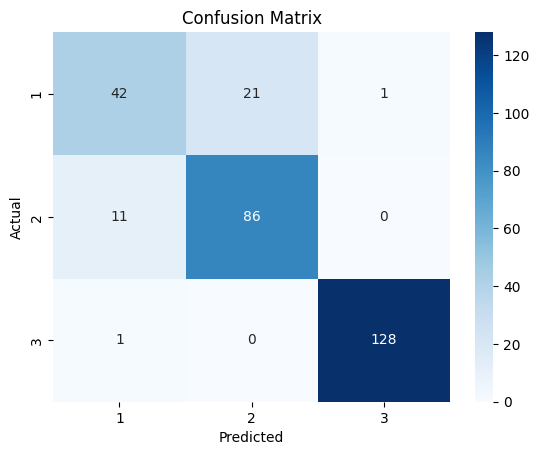

In [138]:
# Confusion Matrix
cm_lda = confusion_matrix(y_test, y_pred, labels=classes)

sns.heatmap(
    cm_lda,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

In [139]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (%): {accuracy * 100:.2f}%")

# Sensitivity and Specificity - Must be done for each class
metrics = []

for i, cls in enumerate(classes):
    TP = cm_lda[i, i]                   # Diagonal is TP
    FN = cm_lda[i, :].sum() - TP        # FN is column sum - TP
    FP = cm_lda[:, i].sum() - TP        # FP is row sum - TP
    TN = cm_lda.sum() - TP - FN - FP    # Rest of matrix (matrix sum - TP - FN - FP)

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    metrics.append({
        "Class": cls,
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    })

metrics_df = pd.DataFrame(metrics)

print("\nSensitivity and Specificity by class:")
print(metrics_df)

# Mean Sensitivity and Mean Specificity
print(f'Mean Sensitivity: {metrics_df["Sensitivity"].mean()}')
print(f'Mean Specificity:{metrics_df["Specificity"].mean()}')

Accuracy (%): 88.28%

Sensitivity and Specificity by class:
   Class   TP  FN  FP   TN  Sensitivity  Specificity
0      1   42  22  12  214     0.656250     0.946903
1      2   86  11  21  172     0.886598     0.891192
2      3  128   1   1  160     0.992248     0.993789
Mean Sensitivity: 0.8450320000532779
Mean Specificity:0.9439610615291976


## Kmeans and GMM

In [140]:
X_combined = pd.concat([X_train, X_test], ignore_index=True)
y_combined = pd.concat([y_train, y_test], ignore_index=True)

In [141]:
# Printing function
def print_info(k, means, sds, weights, type):
    if type == "starting":
        title = "Starting GMM"
    if type == "estimated":
        title = "Estimated GMM"

    print(f"\n{title} means:")
    for j in range(k):
        print(
            f"Component {j+1}: "
            f"mean X1 = {means[j, 0]:.4f}, "
            f"mean X2 = {means[j, 1]:.4f}"
        )

    print(f"\n{title} standard deviations:")
    for j in range(k):
        print(
            f"Component {j+1}: "
            f"sd X1 = {sds[j, 0]:.4f}, "
            f"sd X2 = {sds[j, 1]:.4f}"
        )

    print(f"\n{title} mixing proportions:")
    for j in range(k):
        print(f"Component {j+1}: pi = {weights[j]:.4f}")

    return

# Plotting function
def plot_data(X, labels, centroids_means, k, alg):
    # Colours like the plot you showed
    custom_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

    if k > len(custom_colors):
        raise ValueError("Only 4 custom colours are defined. Add more colours for k > 4.")

    # Assign each observation a colour based on its cluster label
    point_colors = [custom_colors[label] for label in labels]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        X["x1"],
        X["x2"],
        c=point_colors,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5
    )

    plt.scatter(
        centroids_means[:, 0],
        centroids_means[:, 1],
        c="red",
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=1,
        label="Centroid / Mean"
    )

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"{alg} Classification with {k} Components")

    # Legend: display components starting from 1
    legend_elements = []

    for j in range(k):
        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=f"Cluster {j + 1}",
                markerfacecolor=custom_colors[j],
                markeredgecolor="black",
                markersize=8
            )
        )

    legend_elements.append(
        Line2D(
            [0],
            [0],
            marker="X",
            color="w",
            label="Centroid / Mean",
            markerfacecolor="red",
            markeredgecolor="black",
            markersize=10
        )
    )

    plt.legend(
        handles=legend_elements,
        title="Cluster"
    )

    plt.show()
    
    return

In [142]:
# Function that fits modesl and returns results
def kmeans_gmm(k, X):
    ############ Kmeans ############
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)

    kmeans_labels = kmeans.fit_predict(X)  
    kmeans_centroids = kmeans.cluster_centers_

    # Print Centroids
    print(f'Kmeans Centroids: {kmeans_centroids}')

    ############ GMM ############

    # Starting points
    # Starting mean is the centroids
    start_means = kmeans_centroids

    start_weights = []
    start_covariances = []
    start_sds = []

    for j in range(k):
        cluster_points = X[kmeans_labels == j]

        # Mixing proportion / mixing weights are proportion of data points belonging to k
        weight_j = len(cluster_points) / len(X)
        
        # Covariance matrix is the sample variance of the points assigned to cluster k
        cov_j = np.cov(cluster_points.T)
        # Add small value for numerical stability
        cov_j = cov_j + np.eye(2) * 1e-6
        # Standard deviation is sqrt of diagonal elements of the covariance matrix
        sd_j = np.sqrt(np.diag(cov_j))

        start_weights.append(weight_j)
        start_covariances.append(cov_j)
        start_sds.append(sd_j)

    start_weights = np.array(start_weights)
    start_covariances = np.array(start_covariances)
    start_sds = np.array(start_sds)

    # Convert covariance matrices to precision matrices for sklearn GMM
    start_precisions = np.linalg.inv(start_covariances)

    # Print starting information
    print_info(k, start_means, start_sds, start_weights, "starting")

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        means_init=start_means,
        weights_init=start_weights,
        precisions_init=start_precisions,
        n_init=1,
        max_iter=1000,
        reg_covar=1e-6
    )

    gmm_labels = gmm.fit_predict(X)

    gmm_sds = np.sqrt(
        np.diagonal(gmm.covariances_, axis1=1, axis2=2)
    )

    # Print estimated information
    print_info(k, gmm.means_, gmm_sds, gmm.weights_, "estimated")

    # Get aic and bic values
    aic = gmm.aic(X)
    bic = gmm.bic(X)

    print(f"\nAIC = {aic:.4f}")
    print(f"BIC = {bic:.4f}")

    ############ Plots ############
    # Plot Kmeans
    plot_data(X, kmeans_labels, kmeans_centroids, k, "Kmeans")

    # Plot GMM
    plot_data(X, gmm_labels, gmm.means_, k, "GMM")

    # Return all the necessary results
    return {
        "k": k,
        "kmeans": kmeans,
        "kmeans_labels": kmeans_labels,
        "kmeans_centroids": kmeans_centroids,
        "gmm": gmm,
        "gmm_labels": gmm_labels,
        "gmm_sds": gmm_sds,
        "aic": aic,
        "bic": bic
    }


Kmeans Centroids: [[104.53379022 101.62678121]
 [105.90134175 118.90341902]]

Starting GMM means:
Component 1: mean X1 = 104.5338, mean X2 = 101.6268
Component 2: mean X1 = 105.9013, mean X2 = 118.9034

Starting GMM standard deviations:
Component 1: sd X1 = 6.8624, sd X2 = 4.9744
Component 2: sd X1 = 5.5837, sd X2 = 5.0067

Starting GMM mixing proportions:
Component 1: pi = 0.5359
Component 2: pi = 0.4641

Estimated GMM means:
Component 1: mean X1 = 105.6017, mean X2 = 102.5052
Component 2: mean X1 = 104.5752, mean X2 = 119.4258

Estimated GMM standard deviations:
Component 1: sd X1 = 7.0389, sd X2 = 5.6883
Component 2: sd X1 = 5.1567, sd X2 = 5.0024

Estimated GMM mixing proportions:
Component 1: pi = 0.5780
Component 2: pi = 0.4220

AIC = 19694.2276
BIC = 19752.3001


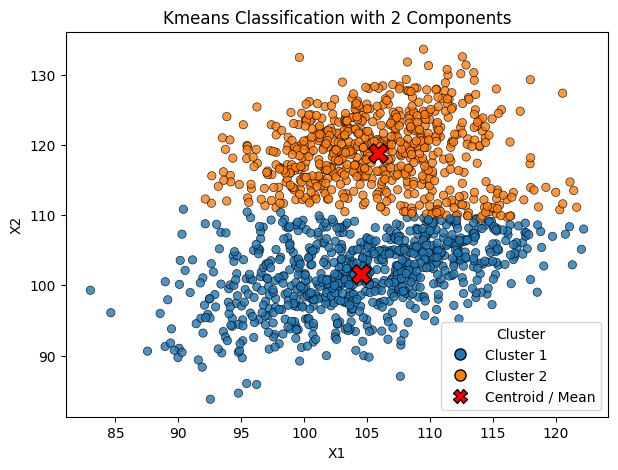

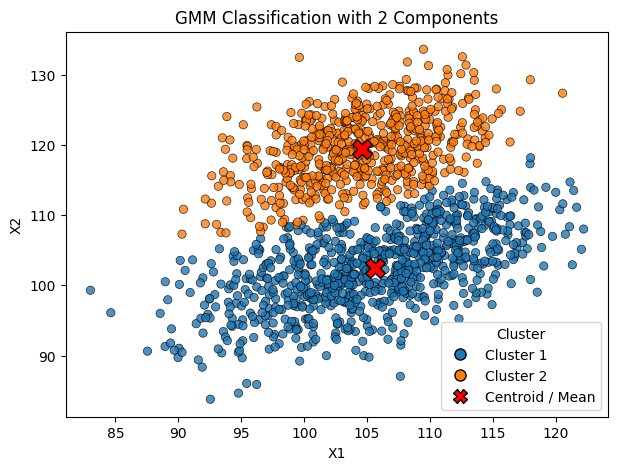

In [143]:
results_2 = kmeans_gmm(2, X_combined)

Kmeans Centroids: [[ 99.74696092  99.30845747]
 [104.87629795 120.00938356]
 [111.03636195 106.03561717]]

Starting GMM means:
Component 1: mean X1 = 99.7470, mean X2 = 99.3085
Component 2: mean X1 = 104.8763, mean X2 = 120.0094
Component 3: mean X1 = 111.0364, mean X2 = 106.0356

Starting GMM standard deviations:
Component 1: sd X1 = 4.5787, sd X2 = 4.9459
Component 2: sd X1 = 4.9881, sd X2 = 4.3945
Component 3: sd X1 = 4.0027, sd X2 = 4.0317

Starting GMM mixing proportions:
Component 1: pi = 0.3000
Component 2: pi = 0.4028
Component 3: pi = 0.2972

Estimated GMM means:
Component 1: mean X1 = 100.5453, mean X2 = 99.6885
Component 2: mean X1 = 104.6707, mean X2 = 119.6564
Component 3: mean X1 = 110.6269, mean X2 = 105.6018

Estimated GMM standard deviations:
Component 1: sd X1 = 5.3160, sd X2 = 5.2141
Component 2: sd X1 = 5.0813, sd X2 = 4.7909
Component 3: sd X1 = 4.5360, sd X2 = 4.5226

Estimated GMM mixing proportions:
Component 1: pi = 0.2975
Component 2: pi = 0.4129
Component 3: 

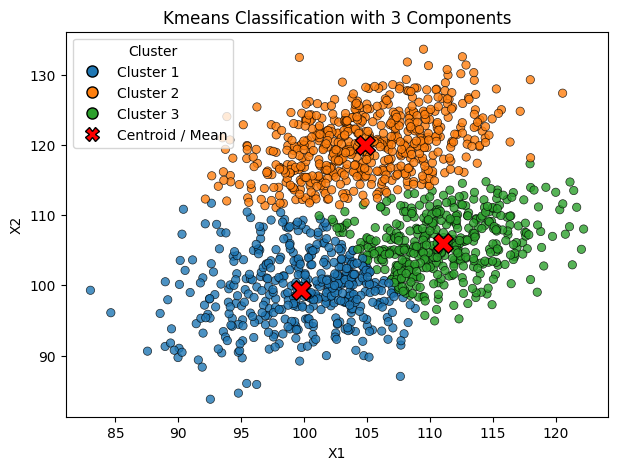

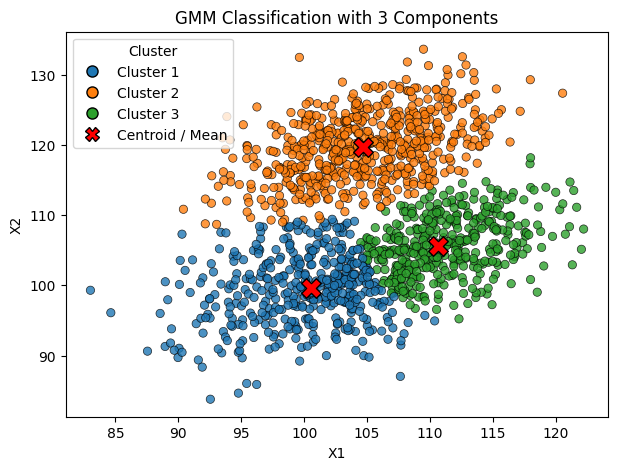

In [144]:
results_3 = kmeans_gmm(3, X_combined)

Kmeans Centroids: [[111.26710817 105.89660337]
 [107.8834491  122.48176946]
 [ 99.88855721  98.53314925]
 [100.7347953  115.48250336]]

Starting GMM means:
Component 1: mean X1 = 111.2671, mean X2 = 105.8966
Component 2: mean X1 = 107.8834, mean X2 = 122.4818
Component 3: mean X1 = 99.8886, mean X2 = 98.5331
Component 4: mean X1 = 100.7348, mean X2 = 115.4825

Starting GMM standard deviations:
Component 1: sd X1 = 3.8095, sd X2 = 3.9774
Component 2: sd X1 = 3.8208, sd X2 = 3.6457
Component 3: sd X1 = 4.6618, sd X2 = 4.3288
Component 4: sd X1 = 3.4678, sd X2 = 3.8975

Starting GMM mixing proportions:
Component 1: pi = 0.2869
Component 2: pi = 0.2303
Component 3: pi = 0.2772
Component 4: pi = 0.2055

Estimated GMM means:
Component 1: mean X1 = 110.6256, mean X2 = 105.6406
Component 2: mean X1 = 107.3547, mean X2 = 121.6554
Component 3: mean X1 = 100.6293, mean X2 = 99.4669
Component 4: mean X1 = 101.2129, mean X2 = 116.7777

Estimated GMM standard deviations:
Component 1: sd X1 = 4.5479,

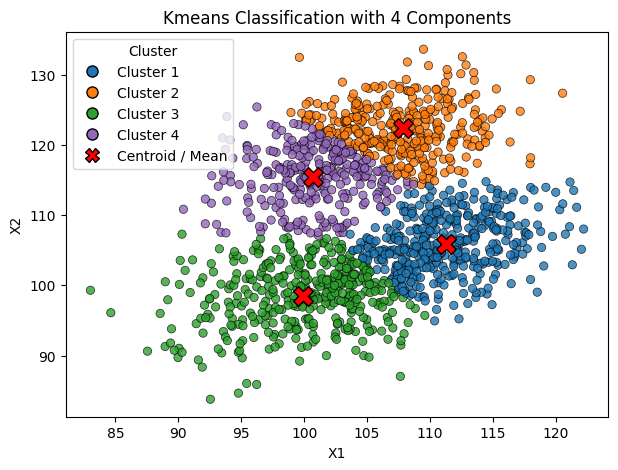

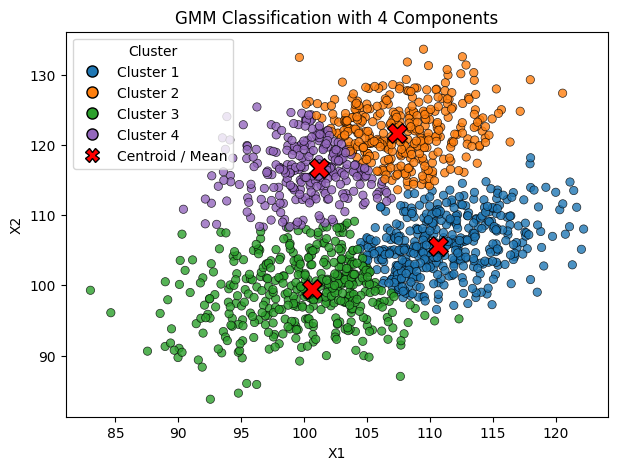

In [145]:
results_4 = kmeans_gmm(4, X_combined)

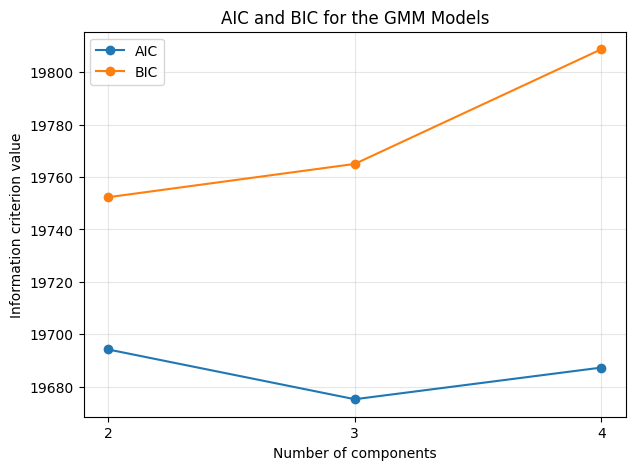

In [151]:
# Best model - plot elbow curve of AIC and BIC for all k

# Create comparison dataframe from stored results
elbow_curve_data = pd.DataFrame({
    "Components": [
        results_2["k"],
        results_3["k"],
        results_4["k"]
    ],
    "AIC": [
        results_2["aic"],
        results_3["aic"],
        results_4["aic"]
    ],
    "BIC": [
        results_2["bic"],
        results_3["bic"],
        results_4["bic"]
    ]
})

plt.figure(figsize=(7, 5))

plt.plot(
    elbow_curve_data["Components"],
    elbow_curve_data["AIC"],
    marker="o",
    label="AIC"
)

plt.plot(
    elbow_curve_data["Components"],
    elbow_curve_data["BIC"],
    marker="o",
    label="BIC"
)

plt.xlabel("Number of components")
plt.ylabel("Information criterion value")
plt.title("AIC and BIC for the GMM Models")
plt.xticks(elbow_curve_data["Components"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [150]:
elbow_curve_data

,Components,AIC,BIC
0,2,19694.227625,19752.300132
1,3,19675.253269,19765.001689
2,4,19687.321824,19808.746158


In [152]:
# Hard classification comparison

# True labels
y_true = y_combined.values.ravel()
# GMM hard classification labels
gmm3_labels = results_3["gmm_labels"]

# Raw comparison
raw_table = pd.crosstab(
    y_true,
    gmm3_labels,
    rownames=["True gr"],
    colnames=["Raw GMM cluster"]
)

print("Raw comparison table:")
print(raw_table)

# Match GMM clusters to true labels
# Rows = true groups
# Columns = GMM clusters
matching_matrix = raw_table.values
row_ind, col_ind = linear_sum_assignment(-matching_matrix)

# True labels and raw cluster labels
true_classes = raw_table.index.to_numpy()
cluster_classes = raw_table.columns.to_numpy()

# Create mapping: raw GMM cluster -> true group
cluster_to_label = {}

for r, c in zip(row_ind, col_ind):
    true_label = true_classes[r]
    cluster_label = cluster_classes[c]
    cluster_to_label[cluster_label] = true_label

print("\nCluster to true label mapping:")
print(cluster_to_label)

# Apply mapping
gmm3_matched_labels = np.array([
    cluster_to_label[label] for label in gmm3_labels
])

# Matched confusion matrix
cm_matched = confusion_matrix(
    y_true,
    gmm3_matched_labels,
    labels=true_classes
)

cm_matched_df = pd.DataFrame(
    cm_matched,
    index=[f"{label}" for label in true_classes],
    columns=[f"{label}" for label in true_classes]
)

print("\nMatched confusion matrix:")
print(cm_matched_df)

Raw comparison table:
Raw GMM cluster    0    1    2
True gr                       
1                292    7   51
2                125   14  361
3                 12  583    5

Cluster to true label mapping:
{np.int64(0): np.int64(1), np.int64(2): np.int64(2), np.int64(1): np.int64(3)}

Matched confusion matrix:
     1    2    3
1  292   51    7
2  125  361   14
3   12    5  583


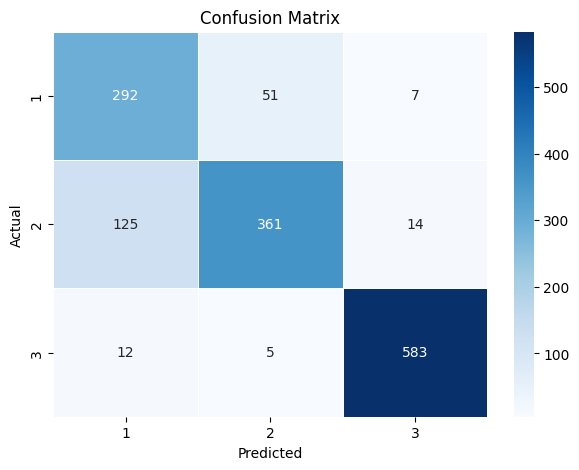

In [153]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_matched_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()